# Recompute integration metrics across trained models

Papermill-parameterized notebook that loads the shared adata once, then iterates over
a list of trained model results folders, loading each model's latent representation
and leiden clusters from saved CSVs, and computing integration metrics.

**Exclusions applied**:
- `pbmc_tea_seq` dataset removed from all computations (labels look randomized)
- `Platelet` in `level_1` replaced with NaN (not a cell type)

**Metrics computed**:
1. Custom sklearn-based metrics (`compute_integration_metrics`): silhouette, ARI, NMI, LISI
2. scib-metrics `Benchmarker`: bio conservation + batch correction suite with signature plot

In [1]:
# Papermill parameters
results_base = "/nfs/team205/vk7/sanger_projects/my_packages/regularizedvi/results"
experiments_tsv_path = "/nfs/team205/vk7/sanger_projects/my_packages/regularizedvi/docs/notebooks/immune_integration/integration_metrics_experiments.tsv"
output_folder = (
    "/nfs/team205/vk7/sanger_projects/my_packages/regularizedvi/results/immune_integration_metrics_comparison"
)
adata_path = "/nfs/team205/vk7/sanger_projects/my_packages/regularizedvi/results/immune_integration/adata_rna.h5ad"
subsample_n = 50000
random_state = 42
n_jobs = 4
exclude_datasets = "pbmc_tea_seq"
exclude_labels = "Platelet"

In [2]:
import os
import time

import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt

# Load experiment registry from TSV
experiments_df = pd.read_csv(experiments_tsv_path, sep="\t")

# Filter to experiments with latent representation outputs
experiment_names = []
for _, row in experiments_df.iterrows():
    outputs_dir = os.path.join(results_base, row["name"], "model", "outputs")
    has_latent = os.path.exists(os.path.join(outputs_dir, "X_scVI.csv")) or os.path.exists(
        os.path.join(outputs_dir, "X_regularizedvi.csv")
    )
    if has_latent:
        experiment_names.append(row["name"])

results_folders = [os.path.join(results_base, name) for name in experiment_names]
os.makedirs(output_folder, exist_ok=True)
print(f"Models to evaluate: {len(experiment_names)} / {len(experiments_df)} in TSV")
print(f"Output folder: {output_folder}")

Models to evaluate: 53 / 53 in TSV
Output folder: /nfs/team205/vk7/sanger_projects/my_packages/regularizedvi/results/immune_integration_metrics_comparison


In [3]:
print(f"Loading adata from {adata_path}...")
t0 = time.time()
adata = sc.read_h5ad(adata_path)
print(f"Loaded: {adata.shape} in {time.time() - t0:.1f}s")

Loading adata from /nfs/team205/vk7/sanger_projects/my_packages/regularizedvi/results/immune_integration/adata_rna.h5ad...


Loaded: (706322, 25629) in 30.9s


In [4]:
# Apply exclusions
n_before = adata.n_obs

# Exclude datasets
if exclude_datasets:
    _excl = [s.strip() for s in exclude_datasets.split(",")]
    adata = adata[~adata.obs["dataset"].isin(_excl)].copy()
    print(f"Excluded datasets {_excl}: {n_before} -> {adata.n_obs} cells")

# Exclude labels (set to NaN so metrics filter them out)
if exclude_labels:
    _excl_labels = [s.strip() for s in exclude_labels.split(",")]
    for lab in _excl_labels:
        n_match = (adata.obs["level_1"] == lab).sum()
        adata.obs.loc[adata.obs["level_1"] == lab, "level_1"] = np.nan
        print(f"Excluded label '{lab}': {n_match} cells set to NaN")

# Verify labelled cell count
has_label = adata.obs["level_1"].notna() & (adata.obs["level_1"] != "") & (adata.obs["level_1"].astype(str) != "nan")
print(f"\nFiltered adata: {adata.n_obs} cells, {has_label.sum()} labelled")
print(f"Datasets: {sorted(adata.obs['dataset'].unique().tolist())}")
print(f"Labels: {sorted(adata.obs.loc[has_label, 'level_1'].unique().tolist())}")

all_obs_names = set(adata.obs_names)

Excluded datasets ['pbmc_tea_seq']: 706322 -> 647171 cells
Excluded label 'Platelet': 0 cells set to NaN

Filtered adata: 647171 cells, 194396 labelled
Datasets: ['bone_marrow', 'covid_pbmc', 'crohns_pbmc', 'infant_adult_spleen', 'lung_spleen_gse319044', 'neat_seq_cd4t']
Labels: ['Activated B', 'B1 B', 'CD4+ T-cell lineage', 'CD8+ T-cell lineage', 'DC lineage', 'Developing B', 'Erythroid lineage', 'G/M prog', 'HSCs', 'ID2-hi myeloid prog', 'IFN-responding T', 'Lymph prog', 'MAIT', 'MK/E prog', 'Memory B', 'Monocyte lineage', 'NK-cell lineage', 'Naive B', 'Plasma B cell', 'T central memory', 'gamma-delta T']


In [5]:
# Compute PCA baseline on log1p(raw counts) — no library-size normalization
# Used as pre_integrated_embedding_obsm_key for Benchmarker's PCR comparison metric
print("Computing PCA baseline on log1p(raw counts)...")
t0 = time.time()

adata_pca = adata.copy()
sc.pp.log1p(adata_pca)
sc.pp.pca(adata_pca, n_comps=100, svd_solver="arpack")
X_pca = adata_pca.obsm["X_pca"]

# Check PC1 correlation with total counts — remove if dominated by library size
total_counts = np.asarray(adata.X.sum(axis=1)).ravel()
pc1_corr = np.corrcoef(X_pca[:, 0], total_counts)[0, 1]
print(f"PC1 correlation with total counts: {pc1_corr:.4f}")
if abs(pc1_corr) > 0.5:
    print(f"Removing PC1 (high correlation: {pc1_corr:.4f})")
    X_pca = X_pca[:, 1:]  # Keep 99 PCs

adata.obsm["X_pca_baseline"] = X_pca
del adata_pca
print(f"PCA baseline: {X_pca.shape} in {time.time() - t0:.1f}s")

Computing PCA baseline on log1p(raw counts)...


PC1 correlation with total counts: 0.9258
Removing PC1 (high correlation: 0.9258)
PCA baseline: (647171, 99) in 1248.2s


## 1. Custom integration metrics (sklearn-based)

In [6]:
from regularizedvi.plt import compute_integration_metrics

custom_metrics = {}

for results_folder in results_folders:
    model_name = os.path.basename(results_folder)
    outputs_dir = os.path.join(results_folder, "model", "outputs")

    # Handle both X_scVI.csv and X_regularizedvi.csv
    scvi_path = os.path.join(outputs_dir, "X_scVI.csv")
    if not os.path.exists(scvi_path):
        scvi_path = os.path.join(outputs_dir, "X_regularizedvi.csv")
    leiden_path = os.path.join(outputs_dir, "leiden_k50.csv")

    if not os.path.exists(scvi_path):
        print(f"SKIP {model_name}: no latent CSV found")
        continue

    print(f"\n{'=' * 60}")
    print(f"Processing: {model_name}")
    print(f"{'=' * 60}")

    t0 = time.time()
    X_scVI_df = pd.read_csv(scvi_path, index_col=0)
    leiden_df = pd.read_csv(leiden_path, index_col=0)
    print(f"  Loaded CSVs: latent {X_scVI_df.shape}, leiden {leiden_df.shape} ({time.time() - t0:.1f}s)")

    # Intersect with filtered adata
    common_obs = sorted(set(X_scVI_df.index) & all_obs_names)
    print(f"  Model cells: {len(X_scVI_df)}, adata cells: {adata.n_obs}, intersection: {len(common_obs)}")

    if len(common_obs) < 1000:
        print(f"  SKIP: too few overlapping cells ({len(common_obs)})")
        continue

    # Subset adata and inject model outputs
    adata_sub = adata[common_obs].copy()
    adata_sub.obsm["X_scVI"] = X_scVI_df.loc[common_obs].values
    adata_sub.obs["leiden"] = leiden_df.loc[common_obs, "leiden"].astype(str).values

    t0 = time.time()
    metrics_df = compute_integration_metrics(
        adata_sub,
        latent_key="X_scVI",
        label_key="level_1",
        batch_key="batch",
        leiden_key="leiden",
        subsample_n=subsample_n,
        random_state=random_state,
    )
    print(f"  Metrics computed in {time.time() - t0:.1f}s")

    metrics_df["model"] = model_name
    custom_metrics[model_name] = metrics_df

    del adata_sub, X_scVI_df, leiden_df

print(f"\nCompleted {len(custom_metrics)} / {len(results_folders)} models")


Processing: immune_baseline_large


  Loaded CSVs: latent (415902, 256), leiden (415902, 1) (22.9s)


  Model cells: 415902, adata cells: 647171, intersection: 389268



=== Integration Metrics ===
  silhouette_label: 0.0074  [global]
  silhouette_batch: -0.0065  [global]
  ARI_leiden_vs_label: 0.2745  [global]
  NMI_leiden_vs_label: 0.5563  [global]
  iLISI_median: 14.9882  [global]
  iLISI_mean: 15.4117  [global]
  cLISI_median: 2.4680  [global]
  cLISI_mean: 2.6999  [global]
  LISI_subsample_n: 32826.0000  [global]
  silhouette_batch_bone_marrow: -0.0115  [per_study]
  silhouette_batch_crohns_pbmc: -0.0009  [per_study]
  silhouette_batch_lung_spleen_gse319044: 0.0004  [per_study]
  Metrics computed in 76.2s

Processing: immune_baseline_small


  Loaded CSVs: latent (415902, 128), leiden (415902, 1) (11.1s)


...

  Model cells: 415902, adata cells: 647171, intersection: 389268



=== Integration Metrics ===
  silhouette_label: 0.0076  [global]
  silhouette_batch: -0.0056  [global]
  ARI_leiden_vs_label: 0.2500  [global]
  NMI_leiden_vs_label: 0.5554  [global]
  iLISI_median: 14.1757  [global]
  iLISI_mean: 14.7543  [global]
  cLISI_median: 2.3444  [global]
  cLISI_mean: 2.5908  [global]
  LISI_subsample_n: 32826.0000  [global]
  silhouette_batch_bone_marrow: -0.0106  [per_study]
  silhouette_batch_crohns_pbmc: 0.0003  [per_study]
  silhouette_batch_lung_spleen_gse319044: 0.0005  [per_study]
  Metrics computed in 71.0s

Processing: immune_rna_v2_no_tea_disp_data_prior1_small


  Loaded CSVs: latent (415902, 128), leiden (415902, 1) (9.4s)


  Model cells: 415902, adata cells: 647171, intersection: 389268



=== Integration Metrics ===
  silhouette_label: 0.0158  [global]
  silhouette_batch: -0.0043  [global]
  ARI_leiden_vs_label: 0.2276  [global]
  NMI_leiden_vs_label: 0.5762  [global]
  iLISI_median: 10.1118  [global]
  iLISI_mean: 11.9424  [global]
  cLISI_median: 1.6063  [global]
  cLISI_mean: 1.8380  [global]
  LISI_subsample_n: 32826.0000  [global]
  silhouette_batch_bone_marrow: -0.0108  [per_study]
  silhouette_batch_crohns_pbmc: 0.0023  [per_study]
  silhouette_batch_lung_spleen_gse319044: 0.0056  [per_study]
  Metrics computed in 52.6s

Completed 53 / 53 models


In [7]:
# Save custom metrics
if custom_metrics:
    combined_long = pd.concat(custom_metrics.values(), ignore_index=True)
    long_path = os.path.join(output_folder, "custom_metrics_long.csv")
    combined_long.to_csv(long_path, index=False)
    print(f"Saved: {long_path}")

    # Wide format for comparison
    numeric_mask = combined_long["value"].apply(lambda x: isinstance(x, (int, float, np.floating)))
    custom_wide = combined_long[numeric_mask].pivot_table(
        index="metric", columns="model", values="value", aggfunc="first"
    )
    wide_path = os.path.join(output_folder, "custom_metrics_wide.csv")
    custom_wide.to_csv(wide_path)
    print(f"Saved: {wide_path}")

    # Key metrics summary
    key_metrics = [
        "silhouette_label",
        "silhouette_batch",
        "ARI_leiden_vs_label",
        "NMI_leiden_vs_label",
        "iLISI_median",
        "cLISI_median",
    ]
    summary = custom_wide.loc[custom_wide.index.isin(key_metrics)]
    print("\n=== Key Custom Metrics ===")
    display(summary.round(4))

Saved: /nfs/team205/vk7/sanger_projects/my_packages/regularizedvi/results/immune_integration_metrics_comparison/custom_metrics_long.csv
Saved: /nfs/team205/vk7/sanger_projects/my_packages/regularizedvi/results/immune_integration_metrics_comparison/custom_metrics_wide.csv

=== Key Custom Metrics ===


model,immune_baseline_large,immune_baseline_small,immune_burst_prior_int1_large,immune_burst_prior_int1_small,immune_burst_vbs2_int1_large,immune_burst_vbs2_int1_small,immune_burst_vbs_int001_large,immune_burst_vbs_int001_small,immune_burst_vbs_int1_large,immune_burst_vbs_int1_small,...,immune_integration_rna_scvi_baseline,immune_integration_rna_small,immune_integration_rna_small_libvar1,immune_integration_rna_studyqc,immune_integration_rna_studyqc_xlarge,immune_integration_rna_studyqc_xlarge_libvar1,immune_integration_rna_v2,immune_integration_rna_xlarge,immune_rna_v2_no_tea_disp_data_prior1_large,immune_rna_v2_no_tea_disp_data_prior1_small
metric,,,,,,,,,,,,,,,,,,,,,
ARI_leiden_vs_label,0.2745,0.2434,0.2896,0.2311,0.3686,0.2274,0.3457,0.2365,0.2894,0.2439,...,0.1211,0.1895,0.1895,0.1233,0.0385,0.0368,0.1068,0.0398,0.2500,0.2276
NMI_leiden_vs_label,0.5563,0.5803,0.5440,0.5836,0.5883,0.5785,0.5597,0.5843,0.5548,0.5914,...,0.5461,0.5526,0.5516,0.4448,0.2885,0.2900,0.4393,0.2713,0.5554,0.5762
cLISI_median,2.4680,1.6788,2.6684,1.6828,2.4607,1.6173,2.6674,1.6337,2.5447,1.6754,...,1.1257,1.5949,1.5556,2.3387,2.9067,2.8890,2.4104,3.0114,2.3444,1.6063
iLISI_median,14.9882,10.8105,17.4891,10.7504,12.7740,10.4170,14.4109,10.8316,14.5349,10.2973,...,6.4822,7.3504,7.9595,11.2256,8.1917,7.3561,12.3402,8.2460,14.1757,10.1118
silhouette_batch,-0.0065,-0.0052,-0.0055,-0.0033,-0.0076,-0.0024,-0.0090,-0.0032,-0.0051,-0.0025,...,-0.0334,-0.0080,-0.0082,-0.0116,-0.0202,-0.0231,-0.0099,-0.0231,-0.0056,-0.0043
silhouette_label,0.0074,0.0145,0.0056,0.0133,0.0050,0.0141,0.0038,0.0137,0.0055,0.0121,...,0.0505,0.0196,0.0172,0.0083,0.0044,0.0042,0.0075,-0.0012,0.0076,0.0158


## 2. scib-metrics Benchmarker

In [8]:
from scib_metrics.benchmark import Benchmarker, BioConservation, BatchCorrection

# Load all embeddings into a single adata for Benchmarker comparison.
# Strategy: Era V models define the reference cell set. Non-Era-V models
# are included only if they retain >=95% of the reference cells.
INCLUSION_THRESHOLD = 0.95

# Build name -> era lookup from experiments_df (loaded in cell 2)
name_to_era = dict(zip(experiments_df["name"], experiments_df["era"], strict=True))

model_obs_sets = {}
for results_folder in results_folders:
    model_name = os.path.basename(results_folder)
    outputs_dir = os.path.join(results_folder, "model", "outputs")
    scvi_path = os.path.join(outputs_dir, "X_scVI.csv")
    if not os.path.exists(scvi_path):
        scvi_path = os.path.join(outputs_dir, "X_regularizedvi.csv")
    if not os.path.exists(scvi_path):
        continue
    idx = pd.read_csv(scvi_path, usecols=[0]).iloc[:, 0].tolist()
    model_obs_sets[model_name] = set(idx)

# Step 1: Build Era V reference set (intersection of all Era V models + filtered adata)
era_v_sets = {name: obs for name, obs in model_obs_sets.items() if name_to_era.get(name) == 5}
if not era_v_sets:
    raise ValueError("No Era V models found — cannot build reference cell set")

reference_set = all_obs_names.copy()
for obs_set in era_v_sets.values():
    reference_set &= obs_set
print(f"Era V reference set: {len(reference_set)} cells (from {len(era_v_sets)} Era V models)")

# Step 2: Filter non-Era-V models by >=95% inclusion of reference cells
included_models = set(era_v_sets.keys())
excluded_models = []

for name, obs_set in sorted(model_obs_sets.items()):
    if name in era_v_sets:
        continue
    overlap = reference_set & obs_set
    pct = len(overlap) / len(reference_set)
    if pct >= INCLUSION_THRESHOLD:
        included_models.add(name)
        print(f"  INCLUDE {name} (era {name_to_era.get(name, '?')}): {pct:.1%} of reference")
    else:
        excluded_models.append(name)
        print(f"  EXCLUDE {name} (era {name_to_era.get(name, '?')}): {pct:.1%} of reference")

if excluded_models:
    print(f"\nExcluded {len(excluded_models)} models with <{INCLUSION_THRESHOLD:.0%} reference coverage")

# Step 3: Final intersection across included models only
common_all = reference_set.copy()
for name in included_models:
    common_all &= model_obs_sets[name]
common_all = sorted(common_all)
print(
    f"Common cells across {len(included_models)} included models: {len(common_all)} "
    f"({len(common_all) / len(reference_set):.1%} of Era V reference)"
)

# Build adata with all embeddings (included models only)
adata_bench = adata[common_all].copy()

# Add PCA baseline (subset to common cells using O(n) index lookup)
pca_idx = adata.obs_names.get_indexer(common_all)
adata_bench.obsm["X_pca_baseline"] = adata.obsm["X_pca_baseline"][pca_idx]

embedding_keys = []
for results_folder in results_folders:
    model_name = os.path.basename(results_folder)
    if model_name not in included_models:
        continue
    outputs_dir = os.path.join(results_folder, "model", "outputs")
    scvi_path = os.path.join(outputs_dir, "X_scVI.csv")
    if not os.path.exists(scvi_path):
        scvi_path = os.path.join(outputs_dir, "X_regularizedvi.csv")
    if not os.path.exists(scvi_path):
        continue

    X_scVI_df = pd.read_csv(scvi_path, index_col=0)
    obsm_key = f"X_{model_name}"
    adata_bench.obsm[obsm_key] = X_scVI_df.loc[common_all].values
    embedding_keys.append(obsm_key)
    print(f"  Added embedding: {obsm_key} {adata_bench.obsm[obsm_key].shape}")

print(f"\n{len(embedding_keys)} embeddings loaded into adata_bench ({adata_bench.n_obs} cells)")

Era V reference set: 389268 cells (from 12 Era V models)
  INCLUDE immune_integration_rna (era 1): 100.0% of reference
  EXCLUDE immune_integration_rna_baseline_with_bias_bg (era 4): 79.9% of reference
  EXCLUDE immune_integration_rna_baseline_without_bias_bg (era 4): 79.9% of reference
  EXCLUDE immune_integration_rna_bg_flat (era 2): 79.9% of reference


  INCLUDE immune_integration_rna_disp_data_prior1 (era 4): 100.0% of reference
  EXCLUDE immune_integration_rna_dwl2_001 (era 4): 79.9% of reference
  EXCLUDE immune_integration_rna_dwl2_01 (era 4): 79.9% of reference
  EXCLUDE immune_integration_rna_dwl2_01_bias_mean_batchbg02 (era 4): 79.9% of reference
  EXCLUDE immune_integration_rna_dwl2_01_bias_mean_batchbg02_repeat2 (era 4): 79.9% of reference
  EXCLUDE immune_integration_rna_dwl2_01_fsprior5 (era 4): 79.9% of reference
  EXCLUDE immune_integration_rna_dwl2_01_no_init_fsprior5 (era 4): 79.9% of reference
  EXCLUDE immune_integration_rna_dwl2_1 (era 4): 79.9% of reference
  EXCLUDE immune_integration_rna_embryo_es1 (era 3): 79.9% of reference
  EXCLUDE immune_integration_rna_embryo_es2 (era 3): 79.9% of reference
  EXCLUDE immune_integration_rna_embryo_es2_ep47 (era 3): 79.9% of reference
  EXCLUDE immune_integration_rna_embryo_es2_ep47_small (era 3): 79.9% of reference
  EXCLUDE immune_integration_rna_embryo_es2_no_tea (era 3): 

  EXCLUDE immune_integration_rna_embryo_es2_no_tea_disp1 (era 3): 79.9% of reference
  EXCLUDE immune_integration_rna_embryo_es2_no_tea_disp1_dwl2_1 (era 3): 79.9% of reference
  EXCLUDE immune_integration_rna_embryo_es2_no_tea_disp2 (era 3): 79.9% of reference
  EXCLUDE immune_integration_rna_embryo_es2_no_tea_disp2_dwl2_1 (era 3): 79.9% of reference
  EXCLUDE immune_integration_rna_embryo_es2_no_tea_dwl2_1 (era 3): 79.9% of reference
  EXCLUDE immune_integration_rna_embryo_es2_no_tea_dwl2_10 (era 3): 79.9% of reference
  EXCLUDE immune_integration_rna_embryo_es2_no_tea_small (era 3): 79.9% of reference
  EXCLUDE immune_integration_rna_embryo_es2_no_tea_small_disp1 (era 3): 79.9% of reference
  EXCLUDE immune_integration_rna_embryo_es2_no_tea_small_disp1_dwl2_1 (era 3): 79.9% of reference
  EXCLUDE immune_integration_rna_embryo_es2_no_tea_small_disp2 (era 3): 79.9% of reference
  EXCLUDE immune_integration_rna_embryo_es2_no_tea_small_disp2_dwl2_1 (era 3): 79.9% of reference
  EXCLUDE 

  EXCLUDE immune_integration_rna_embryo_es2_small (era 3): 79.9% of reference
  INCLUDE immune_integration_rna_large (era 1): 100.0% of reference
  INCLUDE immune_integration_rna_libvar1 (era 1): 100.0% of reference
  EXCLUDE immune_integration_rna_scvi_baseline (era 1): 79.9% of reference
  EXCLUDE immune_integration_rna_small (era 1): 79.9% of reference
  EXCLUDE immune_integration_rna_small_libvar1 (era 1): 79.9% of reference
  EXCLUDE immune_integration_rna_studyqc (era 2): 79.9% of reference
  EXCLUDE immune_integration_rna_studyqc_xlarge (era 2): 79.9% of reference
  EXCLUDE immune_integration_rna_studyqc_xlarge_libvar1 (era 2): 79.9% of reference
  INCLUDE immune_integration_rna_v2 (era 2): 100.0% of reference
  INCLUDE immune_integration_rna_xlarge (era 1): 100.0% of reference

Excluded 35 models with <95% reference coverage


Common cells across 18 included models: 389268 (100.0% of Era V reference)


...

  Added embedding: X_immune_integration_rna_libvar1 (389268, 256)


  Added embedding: X_immune_integration_rna_v2 (389268, 256)


  Added embedding: X_immune_integration_rna_xlarge (389268, 400)


  Added embedding: X_immune_rna_v2_no_tea_disp_data_prior1_large (389268, 256)


  Added embedding: X_immune_rna_v2_no_tea_disp_data_prior1_small (389268, 128)

18 embeddings loaded into adata_bench (389268 cells)


In [9]:
from sklearn.model_selection import StratifiedShuffleSplit

# Filter to labelled cells for scib Benchmarker
label_key = "level_1"
batch_key = "batch"

mask = (
    adata_bench.obs[label_key].notna()
    & (adata_bench.obs[label_key] != "")
    & (adata_bench.obs[label_key].astype(str) != "nan")
)
adata_eval = adata_bench[mask].copy()
print(f"Labelled cells for scib: {adata_eval.n_obs}")

# Stratified subsample using sklearn (by label + batch)
# Drop cells with singleton strata to satisfy sklearn min 2 per class
scib_max_cells = 50000
if adata_eval.n_obs > scib_max_cells:
    strat = adata_eval.obs[label_key].astype(str) + "___" + adata_eval.obs[batch_key].astype(str)
    # Iteratively merge singletons: first into label-only, then drop remaining
    strat_counts = strat.value_counts()
    singletons = strat_counts[strat_counts < 2].index
    if len(singletons) > 0:
        print(f"  Merging {len(singletons)} singleton label+batch strata into label-only strata")
        strat = strat.copy()
        strat[strat.isin(singletons)] = adata_eval.obs.loc[strat.isin(singletons), label_key].astype(str)
    # Drop any remaining singletons (labels with only 1 cell in common intersection)
    strat_counts2 = strat.value_counts()
    remaining_singletons = strat_counts2[strat_counts2 < 2].index
    if len(remaining_singletons) > 0:
        drop_mask = strat.isin(remaining_singletons)
        print(f"  Dropping {drop_mask.sum()} cells with singleton labels: {remaining_singletons.tolist()}")
        adata_eval = adata_eval[~drop_mask].copy()
        strat = strat[~drop_mask]
    sss = StratifiedShuffleSplit(n_splits=1, train_size=scib_max_cells, random_state=random_state)
    sample_idx, _ = next(sss.split(np.zeros(len(strat)), strat))
    adata_eval = adata_eval[sample_idx].copy()
    print(f"Subsampled to {adata_eval.n_obs} cells for scib Benchmarker")

print(f"  Labels: {adata_eval.obs[label_key].nunique()}")
print(f"  Batches: {adata_eval.obs[batch_key].nunique()}")

# Run Benchmarker
t0 = time.time()
bm = Benchmarker(
    adata_eval,
    batch_key=batch_key,
    label_key=label_key,
    embedding_obsm_keys=embedding_keys,
    pre_integrated_embedding_obsm_key="X_pca_baseline",
    bio_conservation_metrics=BioConservation(
        isolated_labels=True,
        nmi_ari_cluster_labels_kmeans=True,
        silhouette_label=True,
        clisi_knn=True,
    ),
    batch_correction_metrics=BatchCorrection(
        ilisi_knn=True,
        kbet_per_label=True,
        graph_connectivity=True,
        pcr_comparison=True,
    ),
    n_jobs=n_jobs,
)
bm.benchmark()
print(f"scib Benchmarker completed in {time.time() - t0:.1f}s")

Labelled cells for scib: 127671
  Merging 7 singleton label+batch strata into label-only strata
  Dropping 7 cells with singleton labels: ['NK-cell lineage', 'CD4+ T-cell lineage', 'Activated B', 'CD8+ T-cell lineage', 'MAIT', 'Plasma B cell', 'IFN-responding T']


Subsampled to 50000 cells for scib Benchmarker
  Labels: 21
  Batches: 37


Computing neighbors:   0%|          | 0/18 [00:00<?, ?it/s]

Computing neighbors:   6%|▌         | 1/18 [00:33<09:30, 33.59s/it]

Computing neighbors:  11%|█         | 2/18 [00:46<05:43, 21.47s/it]

...

Metrics:  80%|████████  | 8/10 [19:25<01:44, 52.39s/it, Batch correction: pcr_comparison]    

Metrics:  90%|█████████ | 9/10 [19:29<00:37, 37.77s/it, Batch correction: pcr_comparison]

Embeddings: 100%|██████████| 18/18 [9:33:12<00:00, 2168.39s/it]

Embeddings: 100%|██████████| 18/18 [9:33:12<00:00, 1910.69s/it]

scib Benchmarker completed in 34669.1s


In [10]:
# Get results and clean up model names
scib_df = bm.get_results(min_max_scale=False, clean_names=True)

# Replace obsm key prefix "X_" with bare experiment name
scib_df.index = [idx[2:] if isinstance(idx, str) and idx.startswith("X_") else idx for idx in scib_df.index]

# Save
scib_path = os.path.join(output_folder, "scib_metrics.csv")
scib_df.to_csv(scib_path)
print(f"Saved: {scib_path}")
display(scib_df)

Saved: /nfs/team205/vk7/sanger_projects/my_packages/regularizedvi/results/immune_integration_metrics_comparison/scib_metrics.csv


,Isolated labels,KMeans NMI,KMeans ARI,Silhouette label,cLISI,BRAS,iLISI,KBET,Graph connectivity,PCR comparison,Batch correction,Bio conservation,Total
immune_baseline_large,0.5,0.635065,0.372052,0.48024,0.954642,0.932398,0.108632,0.398631,0.539726,0.894772,0.574832,0.5884,0.582973
immune_baseline_small,0.5,0.637295,0.393421,0.49915,0.983001,0.886013,0.078653,0.333789,0.759702,0.825159,0.576663,0.602573,0.592209
immune_burst_prior_int1_large,0.5,0.631772,0.357231,0.488646,0.949168,0.936345,0.125561,0.404484,0.469594,0.899168,0.56703,0.585363,0.57803
immune_burst_prior_int1_small,0.5,0.629182,0.372477,0.501593,0.983232,0.882829,0.078284,0.324424,0.765496,0.822578,0.574722,0.597297,0.588267
immune_burst_vbs2_int1_large,0.5,0.656162,0.416918,0.479767,0.953832,0.933444,0.110717,0.39916,0.517862,0.896705,0.571577,0.601336,0.589432
immune_burst_vbs2_int1_small,0.5,0.615868,0.359784,0.501235,0.984564,0.878417,0.071093,0.313524,0.765802,0.806335,0.567034,0.59229,0.582188
immune_burst_vbs_int001_large,0.5,0.641812,0.393133,0.487061,0.951779,0.938753,0.121347,0.41222,0.536305,0.90584,0.582893,0.594757,0.590011
immune_burst_vbs_int001_small,0.5,0.633793,0.376713,0.504069,0.984575,0.883759,0.075121,0.305124,0.772823,0.817322,0.57083,0.59983,0.58823
immune_burst_vbs_int1_large,0.5,0.636479,0.377412,0.491864,0.953866,0.933564,0.116912,0.384312,0.534219,0.895112,0.572824,0.591924,0.584284
immune_burst_vbs_int1_small,0.5,0.625575,0.368485,0.499883,0.984013,0.87898,0.073465,0.333191,0.772386,0.81137,0.573878,0.595591,0.586906


## 3. scib signature heatmap

Saved heatmap to /nfs/team205/vk7/sanger_projects/my_packages/regularizedvi/results/immune_integration_metrics_comparison/scib_heatmap.{svg,png}


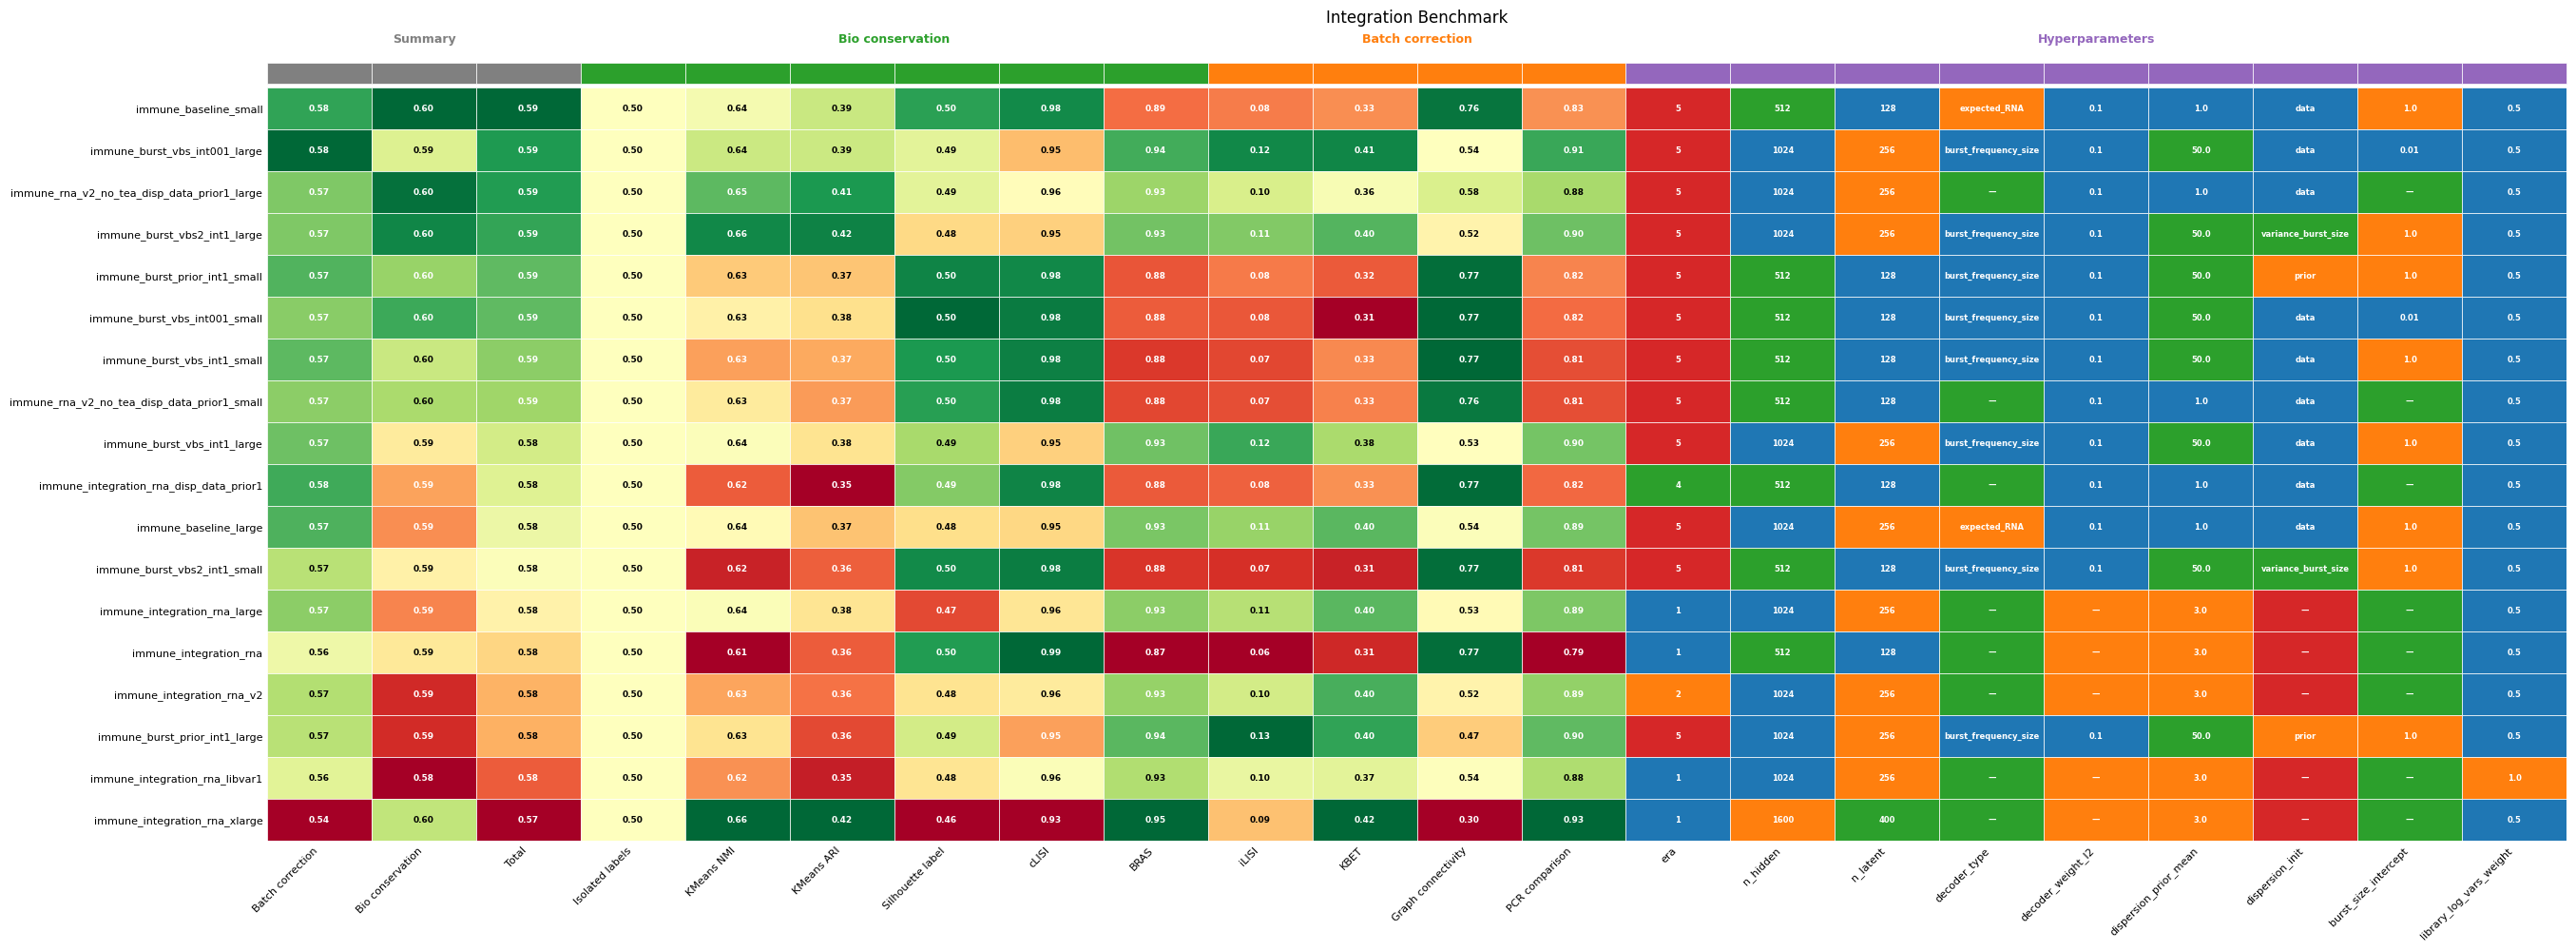

In [11]:
from regularizedvi.plt import plot_integration_heatmap

fig = plot_integration_heatmap(
    scib_df,
    experiments_df=experiments_df,
    hyperparam_cols=[
        "era",
        "n_hidden",
        "n_latent",
        "decoder_type",
        "decoder_weight_l2",
        "dispersion_prior_mean",
        "dispersion_init",
        "burst_size_intercept",
        "library_log_vars_weight",
    ],
    sort_by="Total",
    save_path=os.path.join(output_folder, "scib_heatmap"),
    dpi=150,
)
plt.show()